# Setting up the environment verifying we can read the dataset.
* Path set
* Training dataset is read into the DataFrame (df)
* Printed out first five rows of the DataFrame

In [1]:
# Not sure if this is needed within Kaggle !pip install -U kaggle pandas tensorflow numpy -q # -q for quiet 
import pandas as pd
import numpy as np
import tensorflow as tf
import os
from tensorflow.keras import layers, models

# Silences additional XLA/StreamExecutor noise
tf.get_logger().setLevel('ERROR')

# Set log level to suppress info/warning/error messages from the driver level
# 0 = all logs, 1 = filter out INFO, 2 = filter out WARNING, 3 = filter out ERROR
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

# Define the absolute path based on the Kaggle directory structure
# Note: Kaggle usually maps the competition slug directly under /kaggle/input/
# I used the copy path feature to get the correct path.
DATA_PATH = '/kaggle/input/competitions/WiDSWorldWide_GlobalDathon26'

# Load the training data
train_df = pd.read_csv(f'{DATA_PATH}/train.csv')

# Verify the load
print(f"Training Data Dimensions: {train_df.shape}")
train_df.head()

2026-04-30 17:51:02.102665: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777571462.358668      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777571462.426983      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777571463.011776      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777571463.011829      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777571463.011832      16 computation_placer.cc:177] computation placer alr

Training Data Dimensions: (221, 37)


,event_id,num_perimeters_0_5h,dt_first_last_0_5h,low_temporal_resolution_0_5h,area_first_ha,area_growth_abs_0_5h,area_growth_rel_0_5h,area_growth_rate_ha_per_h,log1p_area_first,log1p_growth,...,dist_fit_r2_0_5h,alignment_cos,alignment_abs,cross_track_component,along_track_speed,event_start_hour,event_start_dayofweek,event_start_month,time_to_hit_hours,event
0,10892457,3,4.265188,0,79.696304,2.875935,0.036086,0.674281,4.390693,1.354787,...,0.886373,-0.054649,0.054649,-1.937219,-0.106026,19,4,5,18.892512,0
1,11757157,2,1.169918,0,8.946749,0.000000,0.000000,0.000000,2.297246,0.000000,...,0.000000,-0.568898,0.568898,-0.000000,-0.000000,4,4,6,22.048108,1
2,11945086,4,4.777526,0,106.482638,0.000000,0.000000,0.000000,4.677329,0.000000,...,0.000000,0.882385,0.882385,0.000000,0.000000,22,4,8,0.888895,1
3,12044083,1,0.000000,1,67.631125,0.000000,0.000000,0.000000,4.228746,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,20,5,8,60.953021,0
4,12052347,2,4.975273,0,35.632874,0.000000,0.000000,0.000000,3.600946,0.000000,...,0.000000,0.934634,0.934634,-0.000000,0.000000,21,5,7,44.990274,0


## Seems like majority of the Hits happen in the first 12 hours.

In [2]:
# Load the datan we can just use train_df
train = train_df
# Check how many 'Hits' occur at each horizon
print(f"Total Events: {train['event'].sum()} / {len(train)}")
for h in [12, 24, 48, 72]:
    hits = train[(train['event'] == 1) & (train['time_to_hit_hours'] <= h)]
    print(f"Hits by {h}h: {len(hits)}")

Total Events: 69 / 221
Hits by 12h: 49
Hits by 24h: 63
Hits by 48h: 66
Hits by 72h: 69


## Setting up functions to run for model.

In [3]:
def engineer_fire_features(df):
    df = df.copy()
    
    # 1. Projected Time to Impact
    df['time_to_contact_est'] = df['dist_min_ci_0_5h'] / (df['closing_speed_m_per_h'].clip(lower=1e-5))
    
    # 2. Scale vs. Distance Interaction
    df['area_to_dist_ratio'] = df['log1p_area_first'] / (df['dist_min_ci_0_5h'] + 1)
    
    # 3. Peak Burn Time Flag
    df['is_peak_burn_time'] = df['event_start_hour'].apply(lambda x: 1 if 12 <= x <= 18 else 0)
    
    # 4. Handle Distance Acceleration
    df['is_accelerating'] = (df['dist_accel_m_per_h2'] > 0).astype(int)

    # 5. REPLACEMENT Interaction: Velocity Proximity Index
    # Uses 'closing_speed_m_per_h' (which exists in your list) instead of wind
    df['velocity_proximity_index'] = df['closing_speed_m_per_h'] * (1 / (df['dist_min_ci_0_5h'] + 1))
    
    return df

In [4]:
def prepare_targets(df):
    """
    Converts survival data into 4 binary horizon labels.
    Required for the Incremental/Multi-Task model.
    """
    horizons = [12, 24, 48, 72]
    targets = []
    
    for _, row in df.iterrows():
        label = []
        for h in horizons:
            # If the fire hit (event=1) AND happened by horizon 'h'
            if row['event'] == 1 and row['time_to_hit_hours'] <= h:
                label.append(1)
            else:
                label.append(0)
        targets.append(label)
        
    return np.array(targets)

In [5]:
def weighted_survival_loss(y_true, y_pred):
    # Weights for [12h, 24h, 48h, 72h]
    # Submission Format CSV with one row per event_id and four probability columns: event_id, prob_12h, prob_24h, prob_48h, prob_72h
    # We normalize these so they sum to 1 or stay relative to competition weights 
    # We need to include a small penalty for 12h to help C-index 
    weights = tf.constant([0.1, 0.3, 0.4, 0.3], dtype=tf.float32)

    # Standard Binary Cross Entropy for each output
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)

    # Manual Binary Cross Entropy calculation to keep the [Batch, 4] shape
    # We add a tiny epsilon (1e-7) to prevent log(0) which causes NaN
    epsilon = 1e-7
    y_pred = tf.clip_by_value(y_pred, epsilon, 1.0 - epsilon)
    
    # This computes loss for EVERY horizon for EVERY fire: shape [Batch, 4]
    bce_elements = - (y_true * tf.math.log(y_pred) + (1 - y_true) * tf.math.log(1 - y_pred))

    # Apply weights across the last dimension (the 4 horizons)
    weighted_bce = bce_elements * weights
    return tf.reduce_mean(tf.reduce_sum(weighted_bce, axis=-1))
    

In [6]:
def build_incremental_model(input_shape):
    inputs = layers.Input(shape=(input_shape,))
    
    # Shared Backbone for feature extraction
    x = layers.Dense(32, activation='swish')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    
    x = layers.Dense(16, activation='swish')(x)
    x = layers.Dropout(0.3)(x)
    
    # Heads: Predict the INCREMENTAL risk for each horizon
    # h12_risk, h24_extra, h48_extra, h72_extra
    incremental_risk = layers.Dense(4, activation='sigmoid')(x)
    
    # Cumulative Sum enforces: prob_12h <= prob_24h <= prob_48h <= prob_72h 
    # We clip to 1.0 to ensure valid probability ranges
    outputs = layers.Lambda(lambda x: tf.minimum(tf.math.cumsum(x, axis=1), 1.0))(incremental_risk)
    
    model = models.Model(inputs=inputs, outputs=outputs)
    #model.compile(optimizer='adam', loss=competition_weighted_loss) 
    # This needs to be weighted_survival_loss
    #model.compile(optimizer='adam', loss=weighted_survival_loss)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), 
                  loss=weighted_survival_loss)
    return model

In [7]:
# --- Step 1: Load Data ---
train_df = pd.read_csv(f'{DATA_PATH}/train.csv')
test_df = pd.read_csv(f'{DATA_PATH}/test.csv')

# --- Step 2: Engineer Features ---
train_df = engineer_fire_features(train_df)
test_df = engineer_fire_features(test_df)

# --- Step 3: Prepare for Training ---
# Ensure you drop the targets and ID before scaling
# 1. Define training features (X) and labels (y)
X = train_df.drop(columns=['event_id', 'time_to_hit_hours', 'event'])
y = prepare_targets(train_df) 

# 2. CRITICAL: Align X_test columns to match X exactly
# This ensures new momentum features are included and IDs/targets are excluded
X_test = test_df[X.columns]

# 3. Scale the data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X).astype('float32')
X_test_scaled = scaler.transform(X_test).astype('float32')
# X_scaled = scaler.fit_transform(X)
# X_test_scaled = scaler.transform(test_df.drop(columns=['event_id']))

# --- Step 4: Build and Train ---
# Pass the new input shape (which is now larger due to new features)
model = build_incremental_model(X_scaled.shape[1])

# Re-introduce your fine-tuning callbacks for the final push
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=15, 
    restore_best_weights=True
)

lr_schedule = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.5, 
    patience=5, 
    min_lr=0.0001, 
    verbose=1
)

model.fit(
    X_scaled, y, 
    epochs=150,          # Higher epochs allowed because of EarlyStopping
    batch_size=8, 
    validation_split=0.2,
    callbacks=[early_stop, lr_schedule]
)

# model.fit(X_scaled, y, epochs=50, batch_size=16, validation_split=0.2)

Epoch 1/150


2026-04-30 17:51:33.984675: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 9.3666 - val_loss: 9.3846 - learning_rate: 0.0010
Epoch 2/150
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 9.2476 - val_loss: 9.1521 - learning_rate: 0.0010
Epoch 3/150
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 9.3448 - val_loss: 8.9340 - learning_rate: 0.0010
Epoch 4/150
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 8.4731 - val_loss: 8.7267 - learning_rate: 0.0010
Epoch 5/150
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 7.9187 - val_loss: 8.6483 - learning_rate: 0.0010
Epoch 6/150
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 8.8698 - val_loss: 8.4210 - learning_rate: 0.0010
Epoch 7/150
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 7.3066 - val_loss: 7.7532 - learning_rate: 0.0010
Epoch 8/150
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 7.3106 - val_loss: 7.0128 - learning_rate: 0.0010
Epoch 9/150
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.0532 - val_loss: 6.7532 - learning_rate: 0.0010
Epoch 10/150
22/22 ━━━━━━━━━━━

# Let's see if this worked

In [8]:
# Generate predictions
test_preds = model.predict(X_test_scaled)

# Check the first fire to ensure probabilities are increasing (Monotonicity)
print("Sample Prediction (12h, 24h, 48h, 72h):")
print(test_preds[0])

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Sample Prediction (12h, 24h, 48h, 72h):
[0.05274048 0.05899556 0.11115466 0.2429616 ]


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


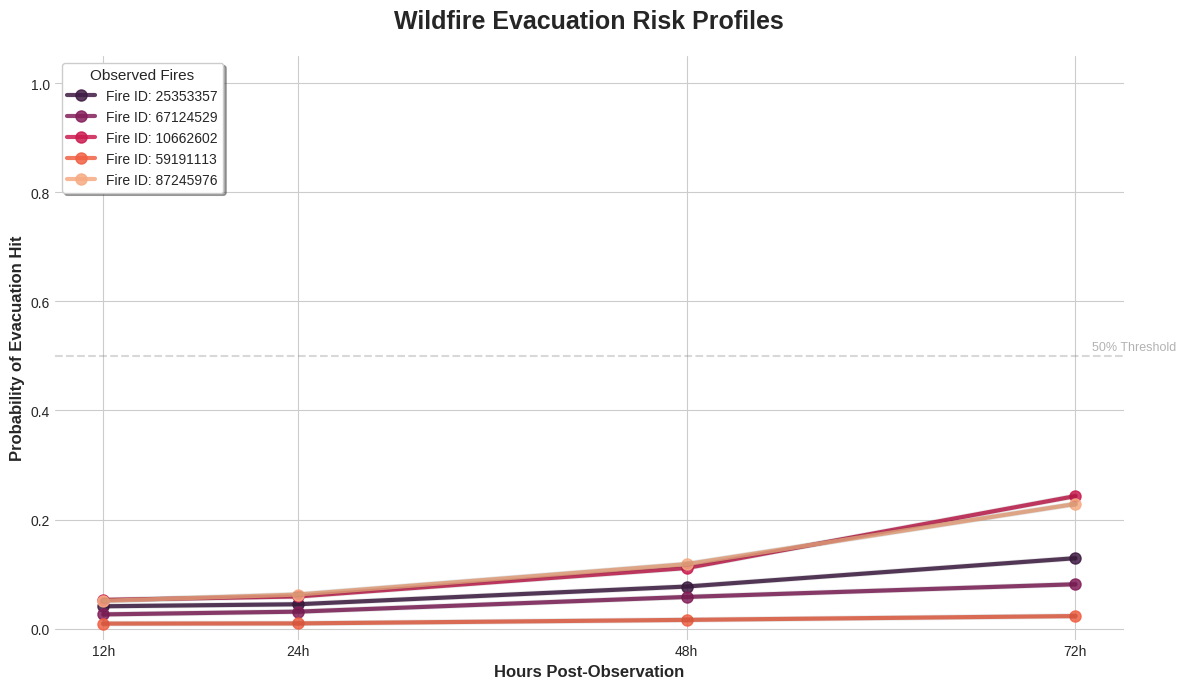

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a professional theme I like this theme better
plt.style.use('seaborn-v0_8-whitegrid') 
plt.rcParams['font.family'] = 'sans-serif'

# 1. Initialize the figure
fig, ax = plt.subplots(figsize=(12, 7), dpi=100)

# 2. Create a high-contrast color palette
palette = sns.color_palette("rocket", n_colors=5) 

# 3. Plot the data
horizons = [12, 24, 48, 72]
sample_idx = np.random.choice(len(X_test_scaled), 5)
sample_preds = model.predict(X_test_scaled[sample_idx])

for i, pred in enumerate(sample_preds):
    fire_id = test_df.iloc[sample_idx[i]]["event_id"]
    ax.plot(horizons, pred, marker='o', markersize=8, label=f'Fire ID: {int(fire_id)}', 
            color=palette[i], linewidth=3, alpha=0.85)
    
    # Optional: Shadow effect for better depth
    ax.plot(horizons, pred, color='black', linewidth=4, alpha=0.1)

# 4. Enhance the "Trader's Dashboard" Aesthetics
ax.set_title('Wildfire Evacuation Risk Profiles', fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('Hours Post-Observation', fontsize=12, fontweight='semibold')
ax.set_ylabel('Probability of Evacuation Hit', fontsize=12, fontweight='semibold')

# Set specific limits and ticks for clarity
ax.set_ylim(-0.02, 1.05)
ax.set_xticks(horizons)
ax.set_xticklabels(['12h', '24h', '48h', '72h'])

# Add a subtle horizontal line at 50% risk
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.3)
ax.text(73, 0.51, '50% Threshold', color='gray', alpha=0.6, fontsize=9)

# Legend and Grid
ax.legend(title="Observed Fires", title_fontsize='11', frameon=True, shadow=True, loc='upper left')
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


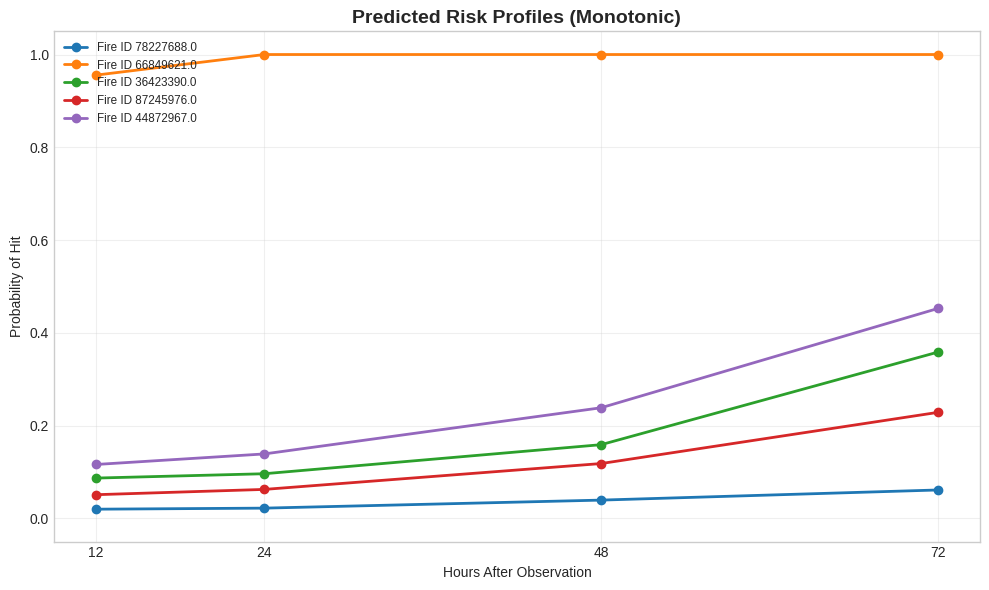

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Create a figure - if history is missing, we'll just show the Risk Profiles
if 'history' in globals():
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
else:
    fig, ax2 = plt.subplots(1, 1, figsize=(10, 6))
    ax1 = None

# --- Plot 1: Training History ---
if ax1 and 'history' in globals():
    ax1.plot(history.history['loss'], label='Train Loss', color='#2ecc71', lw=3)
    ax1.plot(history.history['val_loss'], label='Val Loss', color='#e74c3c', lw=3)
    ax1.set_title('Learning Convergence', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
elif ax1:
    ax1.text(0.5, 0.5, 'History not found.\nChange to: history = model.fit(...)', ha='center')

# --- Plot 2: Sample Survival Curves (The Risk Profiles) ---
# This will work because your 'model' is already built!
horizons = [12, 24, 48, 72]
# Pick 5 random fires from the test set
sample_idx = np.random.choice(len(X_test_scaled), 5)
sample_preds = model.predict(X_test_scaled[sample_idx])

for i, pred in enumerate(sample_preds):
    ax2.plot(horizons, pred, marker='o', label=f'Fire ID {test_df.iloc[sample_idx[i]]["event_id"]}', lw=2)

ax2.set_title('Predicted Risk Profiles (Monotonic)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Hours After Observation')
ax2.set_ylabel('Probability of Hit')
ax2.set_ylim(-0.05, 1.05)
ax2.set_xticks(horizons)
ax2.legend(loc='upper left', fontsize='small')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [11]:
# First attempt
# 1. Final Feature Engineering Check
# Ensure your test_df has the same engineering as your train_df
test_df_engineered = engineer_fire_features(test_df)
X_test = test_df_engineered.drop(columns=['event_id']).fillna(0)
X_test_scaled = scaler.transform(X_test)

# 2. Generate Final Predictions
final_preds = model.predict(X_test_scaled)

# 3. Format for WiDS Leaderboard
# The columns must be event_id, prob_12h, prob_24h, prob_48h, prob_72h
submission = pd.DataFrame({
    'event_id': test_df['event_id'],
    'prob_12h': final_preds[:, 0],
    'prob_24h': final_preds[:, 1],
    'prob_48h': final_preds[:, 2],
    'prob_72h': final_preds[:, 3]
})

# 4. Export to Kaggle Output
submission.to_csv('submission.csv', index=False)
print("Submission file 'submission.csv' generated successfully!")
submission.head()

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Submission file 'submission.csv' generated successfully!


,event_id,prob_12h,prob_24h,prob_48h,prob_72h
0,10662602,0.052740,0.058996,0.111155,0.242962
1,13353600,0.165344,0.242311,0.415198,0.659771
2,13942327,0.031422,0.037398,0.088179,0.213356
3,16112781,0.151882,0.202410,0.369831,0.487190
4,17132808,0.528348,0.901789,1.000000,1.000000
